100%|██████████| 170M/170M [00:06<00:00, 26.9MB/s] 


Epoch 1/10, Train Acc: 39.47%, Test Acc: 47.55%
Epoch 2/10, Train Acc: 50.53%, Test Acc: 52.24%
Epoch 3/10, Train Acc: 55.57%, Test Acc: 54.94%
Epoch 4/10, Train Acc: 58.92%, Test Acc: 59.10%
Epoch 5/10, Train Acc: 61.63%, Test Acc: 60.20%
Epoch 6/10, Train Acc: 63.71%, Test Acc: 60.87%
Epoch 7/10, Train Acc: 65.45%, Test Acc: 61.58%
Epoch 8/10, Train Acc: 66.84%, Test Acc: 63.29%
Epoch 9/10, Train Acc: 68.28%, Test Acc: 63.65%
Epoch 10/10, Train Acc: 69.26%, Test Acc: 63.66%

LeNet Base Training Time: 45.09 seconds


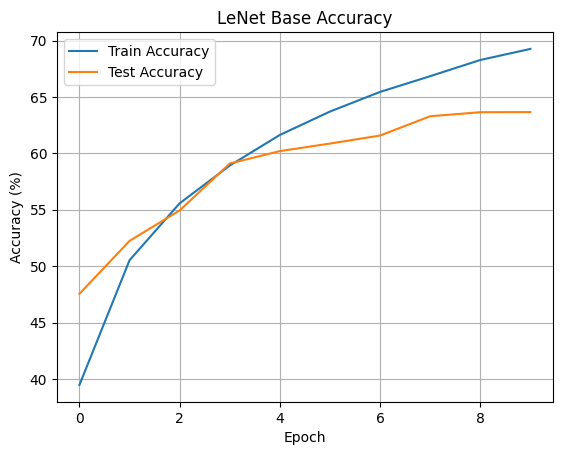

Epoch 1/10, Train Acc: 33.98%, Test Acc: 44.39%
Epoch 2/10, Train Acc: 45.14%, Test Acc: 48.90%
Epoch 3/10, Train Acc: 48.53%, Test Acc: 51.88%
Epoch 4/10, Train Acc: 51.27%, Test Acc: 55.06%
Epoch 5/10, Train Acc: 53.14%, Test Acc: 55.94%
Epoch 6/10, Train Acc: 54.63%, Test Acc: 57.18%
Epoch 7/10, Train Acc: 55.85%, Test Acc: 58.80%
Epoch 8/10, Train Acc: 56.87%, Test Acc: 59.44%
Epoch 9/10, Train Acc: 57.65%, Test Acc: 59.79%
Epoch 10/10, Train Acc: 58.30%, Test Acc: 59.47%

LeNet with Dropout Training Time: 47.24 seconds


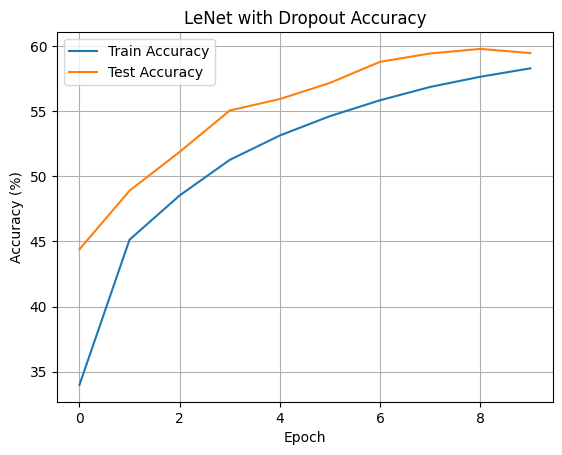

Epoch 1/10, Train Acc: 46.87%, Test Acc: 54.08%
Epoch 2/10, Train Acc: 57.90%, Test Acc: 59.50%
Epoch 3/10, Train Acc: 62.20%, Test Acc: 62.94%
Epoch 4/10, Train Acc: 64.61%, Test Acc: 63.72%
Epoch 5/10, Train Acc: 66.89%, Test Acc: 64.54%
Epoch 6/10, Train Acc: 68.31%, Test Acc: 65.15%
Epoch 7/10, Train Acc: 69.93%, Test Acc: 64.81%
Epoch 8/10, Train Acc: 70.90%, Test Acc: 67.61%
Epoch 9/10, Train Acc: 72.08%, Test Acc: 67.19%
Epoch 10/10, Train Acc: 72.99%, Test Acc: 67.10%

LeNet with BatchNorm Training Time: 43.05 seconds


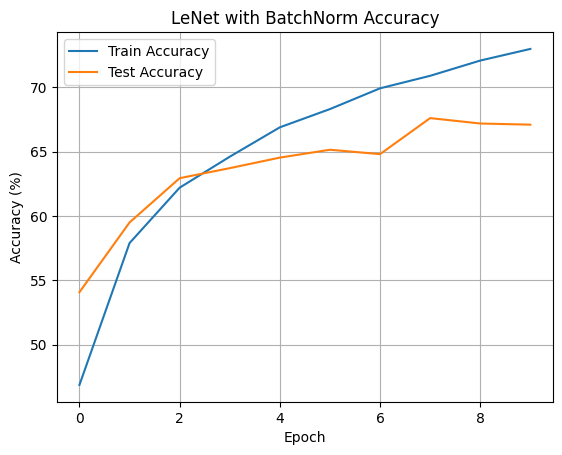

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

class LeNet(nn.Module):
    def __init__(self, dropout=False, batchnorm=False):
        super(LeNet, self).__init__()
        self.use_dropout = dropout
        self.use_batchnorm = batchnorm

        self.conv1 = nn.Conv2d(3, 6, 5)  # 3 channels for color
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.bn1 = nn.BatchNorm2d(6) if batchnorm else nn.Identity()
        self.bn2 = nn.BatchNorm2d(16) if batchnorm else nn.Identity()

        self.dropout = nn.Dropout(p=0.5) if dropout else nn.Identity()

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.max_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def train_and_evaluate(model_name, model):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_acc, test_acc = [], []
    epochs = 10
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        train_acc.append(100 * correct / total)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_acc.append(100 * correct / total)

        print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_acc[-1]:.2f}%, Test Acc: {test_acc[-1]:.2f}%")

    elapsed = time.time() - start_time
    print(f"\n{model_name} Training Time: {elapsed:.2f} seconds")

    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(test_acc, label='Test Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_accuracy.png')
    plt.show()

train_and_evaluate("LeNet Base", LeNet())
train_and_evaluate("LeNet with Dropout", LeNet(dropout=True))
train_and_evaluate("LeNet with BatchNorm", LeNet(batchnorm=True))
